# Skin Degradation Exploratory Data Analysis (Time-Aware)

This notebook analyzes three datasets (`skin-monitor.csv`, `indoor_data.json`, `tomorrow_recent_data.json`).
We separate the analysis into two distinct conditions using exact **time constraints**:
1. **Long time indoor:** Analyzing indoor environment strictly *before* the time the person left the house vs. skin index *before* going out.
2. **Long time outdoor:** Analyzing outdoor environment strictly *during the hours the person was out* vs. skin index change *after* going out.


In [1]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer

# Set plot style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)


## 1. Data Loading and Preprocessing with Time Slicing


In [2]:
# 1.1 Load Skin Data
skin_df = pd.read_csv('../data/skin-monitor.csv')
skin_df.columns = skin_df.columns.str.strip()
skin_df['GoOut'] = skin_df['GoOut'].str.lower()

# Parse datetime (assuming year 2026) and localize to UTC to match JSON files
skin_df['datetime'] = pd.to_datetime('2026/' + skin_df['date'] + ' ' + skin_df['time'], format='%Y/%d/%m %H:%M').dt.tz_localize('UTC')

# 1.2 Load Indoor Data
with open('../data/indoor_data.json', 'r') as f:
    indoor_raw = json.load(f)

indoor_records = [{'datetime': pd.to_datetime(e['time']), 'in_temp': e['values']['temperature'], 'in_humidity': e['values']['humidity']} for e in indoor_raw]
indoor_df = pd.DataFrame(indoor_records)

# 1.3 Load Outdoor Data
with open('../data/tomorrow_recent_data.json', 'r') as f:
    outdoor_raw = json.load(f)
outdoor_records = []
for entry in outdoor_raw:
    row = entry['Values'].copy()
    row['datetime'] = pd.to_datetime(entry['time'])
    outdoor_records.append(row)
outdoor_df = pd.DataFrame(outdoor_records)

outdoor_features = ['temperature', 'humidity', 'uvIndex', 'windSpeed', 'cloudCover', 'dewPoint']


In [3]:
# 1.4 Time-Aware Merging
records = []
for dt, group in skin_df.groupby(skin_df['datetime'].dt.date):
    before = group[group['GoOut'] == 'before']
    after = group[group['GoOut'] == 'after']

    did_go_out = len(after) > 0
    record = {'date': dt, 'went_out': did_go_out}

    time_out = None
    time_in = None

    if not before.empty:
        b_row = before.iloc[-1]
        record['before_water'] = b_row['WATER']
        record['before_elas'] = b_row['ELAS']
        record['before_oil'] = b_row['OIL']
        time_out = b_row['datetime']
    else:
        record['before_water'] = np.nan; record['before_elas'] = np.nan; record['before_oil'] = np.nan

    if not after.empty:
        a_row = after.iloc[-1]
        record['after_water'] = a_row['WATER']
        record['after_elas'] = a_row['ELAS']
        record['after_oil'] = a_row['OIL']
        time_in = a_row['datetime']
    else:
        record['after_water'] = np.nan; record['after_elas'] = np.nan; record['after_oil'] = np.nan

    record['water_diff'] = record['after_water'] - record['before_water']
    record['elas_diff'] = record['after_elas'] - record['before_elas']
    record['oil_diff'] = record['after_oil'] - record['before_oil']

    # Calculate Indoor Metrics (Start of day up to time_out)
    if time_out is not None:
        start_of_day = pd.to_datetime(f"{dt} 00:00:00").tz_localize('UTC')
        indoor_slice = indoor_df[(indoor_df['datetime'] >= start_of_day) & (indoor_df['datetime'] <= time_out)]
        if not indoor_slice.empty:
            record['in_temp_mean'] = indoor_slice['in_temp'].mean()
            record['in_temp_max'] = indoor_slice['in_temp'].max()
            record['in_temp_min'] = indoor_slice['in_temp'].min()
            record['in_humidity_mean'] = indoor_slice['in_humidity'].mean()
            record['in_humidity_max'] = indoor_slice['in_humidity'].max()
            record['in_humidity_min'] = indoor_slice['in_humidity'].min()

    # Calculate Outdoor Metrics (time_out to time_in, padded by 1 hour to handle short trips)
    if time_out is not None and time_in is not None:
        out_start = time_out - pd.Timedelta(hours=1)
        out_end = time_in + pd.Timedelta(hours=1)
        outdoor_slice = outdoor_df[(outdoor_df['datetime'] >= out_start) & (outdoor_df['datetime'] <= out_end)]
        if not outdoor_slice.empty:
            for feat in outdoor_features:
                record[f'out_{feat}_mean'] = outdoor_slice[feat].mean()
                record[f'out_{feat}_max'] = outdoor_slice[feat].max()

    records.append(record)

merged_df = pd.DataFrame(records)

# Calculate Out - In differences
if 'out_temperature_mean' in merged_df.columns and 'in_temp_mean' in merged_df.columns:
    merged_df['temp_diff_out_in'] = merged_df['out_temperature_mean'] - merged_df['in_temp_mean']
    merged_df['humidity_diff_out_in'] = merged_df['out_humidity_mean'] - merged_df['in_humidity_mean']

display(merged_df.head())


,date,went_out,before_water,before_elas,before_oil,after_water,after_elas,after_oil,water_diff,elas_diff,...,out_uvIndex_mean,out_uvIndex_max,out_windSpeed_mean,out_windSpeed_max,out_cloudCover_mean,out_cloudCover_max,out_dewPoint_mean,out_dewPoint_max,temp_diff_out_in,humidity_diff_out_in
0,2026-03-02,True,NaN,NaN,NaN,28.0,48.0,26.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2026-03-03,True,25.0,46.0,25.0,27.0,47.0,26.0,2.0,1.0,...,0.384615,2.0,1.115385,2.7,21.769231,72.0,6.223077,8.2,-11.232692,9.048077
2,2026-03-04,True,28.0,48.0,26.0,22.0,45.0,23.0,-6.0,-3.0,...,0.909091,2.0,0.890909,1.3,33.230000,100.0,7.545455,9.8,-13.152857,26.714286
3,2026-03-05,True,27.0,47.0,26.0,23.0,45.0,24.0,-4.0,-2.0,...,0.769231,2.0,0.646154,1.6,27.986154,100.0,8.384615,8.9,-6.684615,2.479638
4,2026-03-06,False,26.0,47.0,25.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Condition 1: Long Time Indoor
Here we analyze the impact of the **indoor environment** on the **skin indices before going out**.


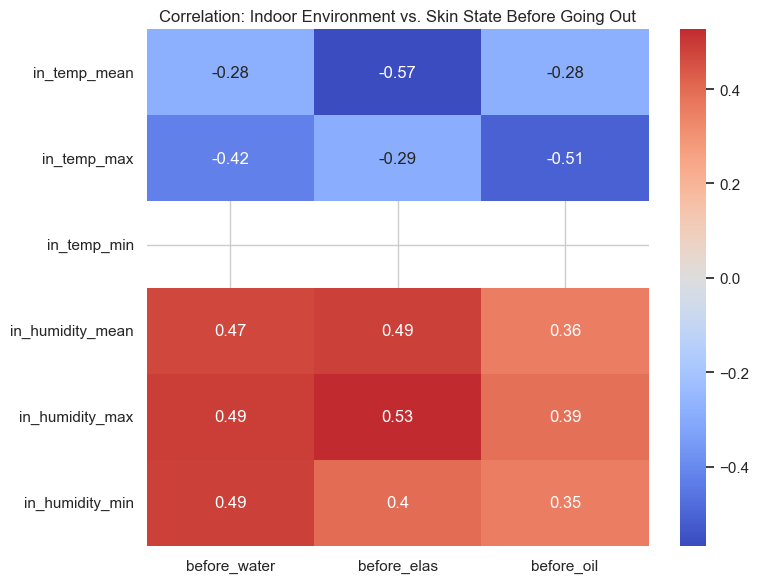

--- Top factors affecting Indoor Water (Higher is better) ---
in_humidity_max     0.492516
in_humidity_min     0.488795
in_humidity_mean    0.473537
in_temp_mean       -0.278029
in_temp_max        -0.423099
in_temp_min              NaN
Name: before_water, dtype: float64

--- Top factors affecting Indoor Elasticity (Higher is better) ---
in_humidity_max     0.526385
in_humidity_mean    0.491102
in_humidity_min     0.396529
in_temp_max        -0.287411
in_temp_mean       -0.567493
in_temp_min              NaN
Name: before_elas, dtype: float64

--- Top factors increasing Indoor Oil (Higher is WORSE) ---
in_humidity_max     0.385520
in_humidity_mean    0.357008
in_humidity_min     0.353738
in_temp_mean       -0.281439
in_temp_max        -0.510226
Name: before_oil, dtype: float64

--- Top factors preventing Indoor Oil (Better) ---
in_humidity_mean    0.357008
in_humidity_min     0.353738
in_temp_mean       -0.281439
in_temp_max        -0.510226
in_temp_min              NaN
Name: before_oil,

In [4]:
# Filter relevant columns for Condition 1
indoor_feat_cols = [c for c in merged_df.columns if c.startswith('in_')]
before_targets = ['before_water', 'before_elas', 'before_oil']

indoor_corr = merged_df[indoor_feat_cols + before_targets].corr().loc[indoor_feat_cols, before_targets]

plt.figure(figsize=(8, 6))
sns.heatmap(indoor_corr, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation: Indoor Environment vs. Skin State Before Going Out')
plt.tight_layout()
plt.show()

print("--- Top factors affecting Indoor Water (Higher is better) ---")
print(indoor_corr['before_water'].sort_values(ascending=False))

print("\n--- Top factors affecting Indoor Elasticity (Higher is better) ---")
print(indoor_corr['before_elas'].sort_values(ascending=False))

print("\n--- Top factors increasing Indoor Oil (Higher is WORSE) ---")
print(indoor_corr['before_oil'].sort_values(ascending=False).head())

print("\n--- Top factors preventing Indoor Oil (Better) ---")
print(indoor_corr['before_oil'].sort_values(ascending=False).tail())


## 3. Condition 2: Long Time Outdoor
Here we analyze the impact of the **outdoor environment**, the **indoor-to-outdoor transition diff**, and the **initial skin state** on the **skin degradation (after - before)**. 
We only consider days where the 'GoOut' event occurred.


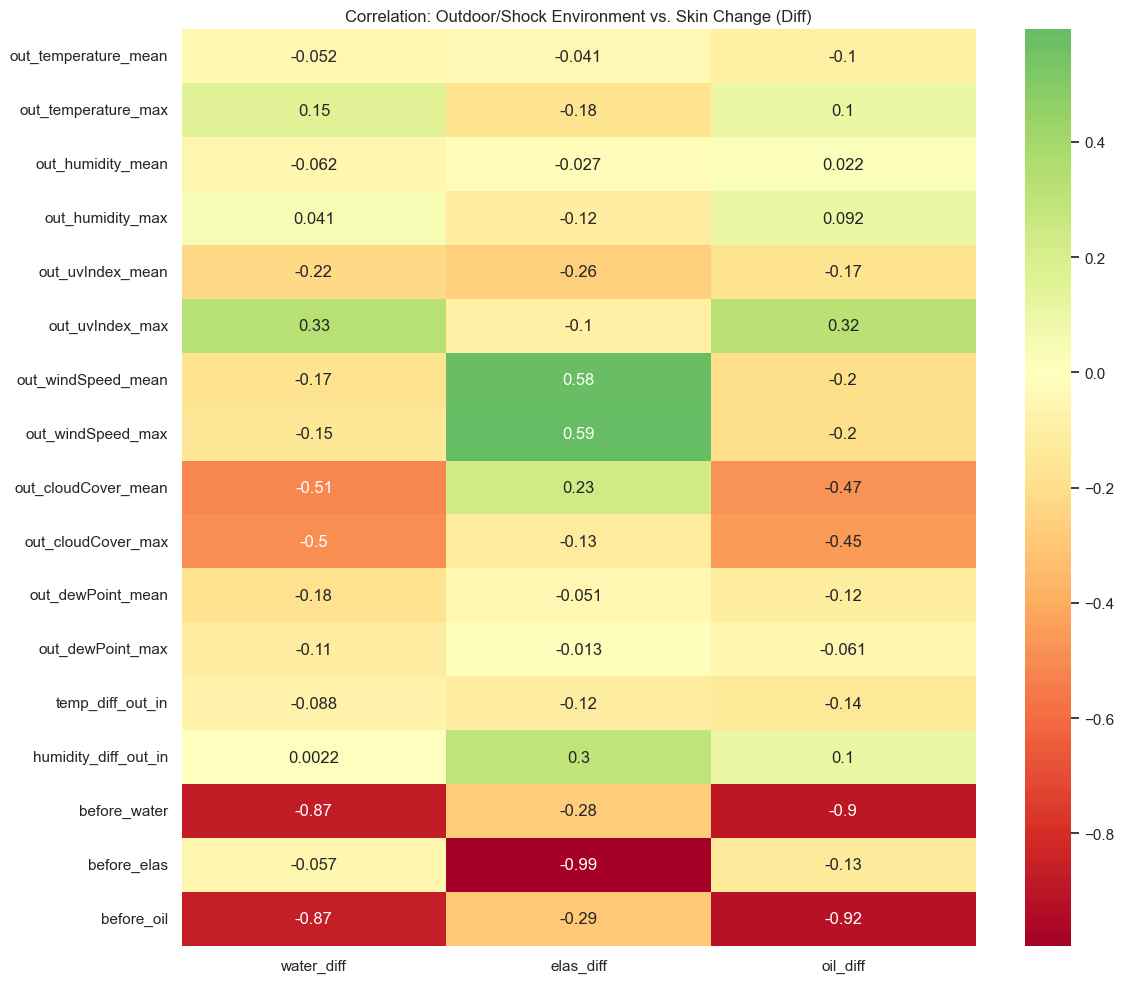

--- Top factors causing OUTDOOR Water Decrease (Negative diff means water drops) ---
before_water          -0.871176
before_oil            -0.866899
out_cloudCover_mean   -0.511423
out_cloudCover_max    -0.497425
out_uvIndex_mean      -0.220470
Name: water_diff, dtype: float64

--- Top factors preserving OUTDOOR Water (Positive diff) ---
out_temperature_mean   -0.052383
humidity_diff_out_in    0.002198
out_humidity_max        0.041278
out_temperature_max     0.154416
out_uvIndex_max         0.328634
Name: water_diff, dtype: float64

--- Top factors causing OUTDOOR Oil Increase (Positive diff, WORSE) ---
out_uvIndex_max         0.315946
humidity_diff_out_in    0.103583
out_temperature_max     0.103493
out_humidity_max        0.092023
out_humidity_mean       0.022143
Name: oil_diff, dtype: float64

--- Top factors preventing OUTDOOR Oil Increase (Negative diff, BETTER) ---
out_windSpeed_max     -0.196283
out_cloudCover_max    -0.448553
out_cloudCover_mean   -0.474900
before_water        

In [5]:
went_out_df = merged_df[merged_df['went_out'] == True].dropna(subset=['water_diff']).copy()

outdoor_feat_cols = [c for c in went_out_df.columns if c.startswith('out_')]
shock_feat_cols = ['temp_diff_out_in', 'humidity_diff_out_in']
initial_state_cols = ['before_water', 'before_elas', 'before_oil']

cond2_features = outdoor_feat_cols + shock_feat_cols + initial_state_cols
diff_targets = ['water_diff', 'elas_diff', 'oil_diff']

outdoor_corr = went_out_df[cond2_features + diff_targets].corr().loc[cond2_features, diff_targets]

plt.figure(figsize=(12, 10))
sns.heatmap(outdoor_corr, annot=True, cmap='RdYlGn', center=0)
plt.title('Correlation: Outdoor/Shock Environment vs. Skin Change (Diff)')
plt.tight_layout()
plt.show()

print("--- Top factors causing OUTDOOR Water Decrease (Negative diff means water drops) ---")
print(outdoor_corr['water_diff'].sort_values().head())

print("\n--- Top factors preserving OUTDOOR Water (Positive diff) ---")
print(outdoor_corr['water_diff'].sort_values().tail())

print("\n--- Top factors causing OUTDOOR Oil Increase (Positive diff, WORSE) ---")
print(outdoor_corr['oil_diff'].sort_values(ascending=False).head())

print("\n--- Top factors preventing OUTDOOR Oil Increase (Negative diff, BETTER) ---")
print(outdoor_corr['oil_diff'].sort_values(ascending=False).tail())


In [6]:
# Zooming in on the Shock Factor (Out - In Diff)
print("Impact of Temperature Shock (Out Temp - In Temp) on Degradation:")
print(outdoor_corr.loc['temp_diff_out_in', diff_targets])

print("\nImpact of Humidity Shock (Out Humid - In Humid) on Degradation:")
print(outdoor_corr.loc['humidity_diff_out_in', diff_targets])


Impact of Temperature Shock (Out Temp - In Temp) on Degradation:
water_diff   -0.087712
elas_diff    -0.116085
oil_diff     -0.141367
Name: temp_diff_out_in, dtype: float64

Impact of Humidity Shock (Out Humid - In Humid) on Degradation:
water_diff    0.002198
elas_diff     0.300203
oil_diff      0.103583
Name: humidity_diff_out_in, dtype: float64
